In [65]:
import pandas as pd  # Data manipulation
import numpy as np  # Numerical computations
import matplotlib.pyplot as plt  # Static plots
import seaborn as sns  # Statistical plots
import missingno as msno  # Missing data visualization

import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style='darkgrid', context='notebook')


In [ ]:
test = pd.read_csv("data/test.csv", on_bad_lines='skip', na_values='?')
train = pd.read_csv("data/train.csv", on_bad_lines='skip', na_values='?')

train = train.drop(columns=['PassengerId'])
train = train.drop(columns=['Name'])
train = train.drop(columns=['Cabin'])

train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])
train['Age'] = train['Age'].fillna(train['Age'].mean())
train['Relatives'] = train['SibSp'] + train['Parch']


sex_categorical_values = {'female': 0, 'male': 1}
embarked_categorical_values = {'S': 0, 'Q':1, 'C':2}
train['Sex'] = train['Sex'].apply(lambda x: sex_categorical_values[x])
train['Embarked'] = train['Embarked'].apply(lambda x: embarked_categorical_values[x])

train.describe().T


,count,mean,std,min,25%,50%,75%,max
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.000000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.000000,3.0,3.0000
Sex,891.0,0.647587,0.477990,0.00,0.0000,1.000000,1.0,1.0000
Age,891.0,29.699118,13.002015,0.42,22.0000,29.699118,35.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.000000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.000000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.454200,31.0,512.3292
Embarked,891.0,0.463524,0.791503,0.00,0.0000,0.000000,1.0,2.0000


In [67]:
train['Embarked'].mode()[0]

'S'

In [64]:
train.duplicated().sum()


np.int64(15)

In [ ]:
train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: str

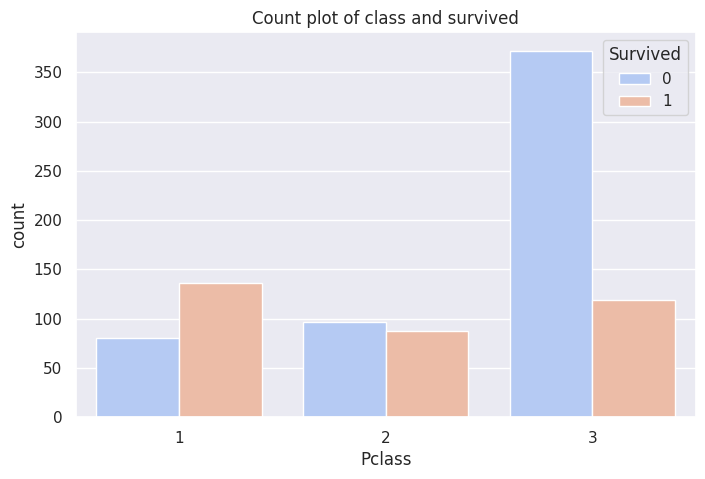

In [112]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Pclass', data=train, hue='Survived', palette='coolwarm')
plt.title('Count plot of class and survived')
plt.show()

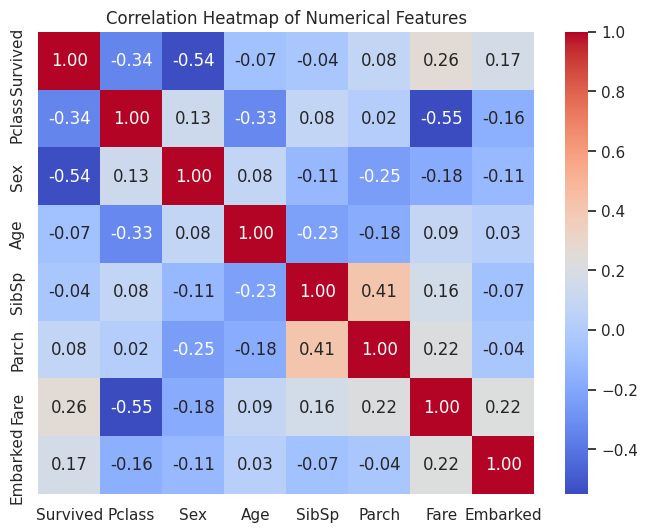

In [113]:
plt.figure(figsize=(8, 6))
numerical_columns = train.select_dtypes(include=['int64', 'float64']).columns  # Select only numerical columns
sns.heatmap(train[numerical_columns].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

<Figure size 1000x1000 with 0 Axes>

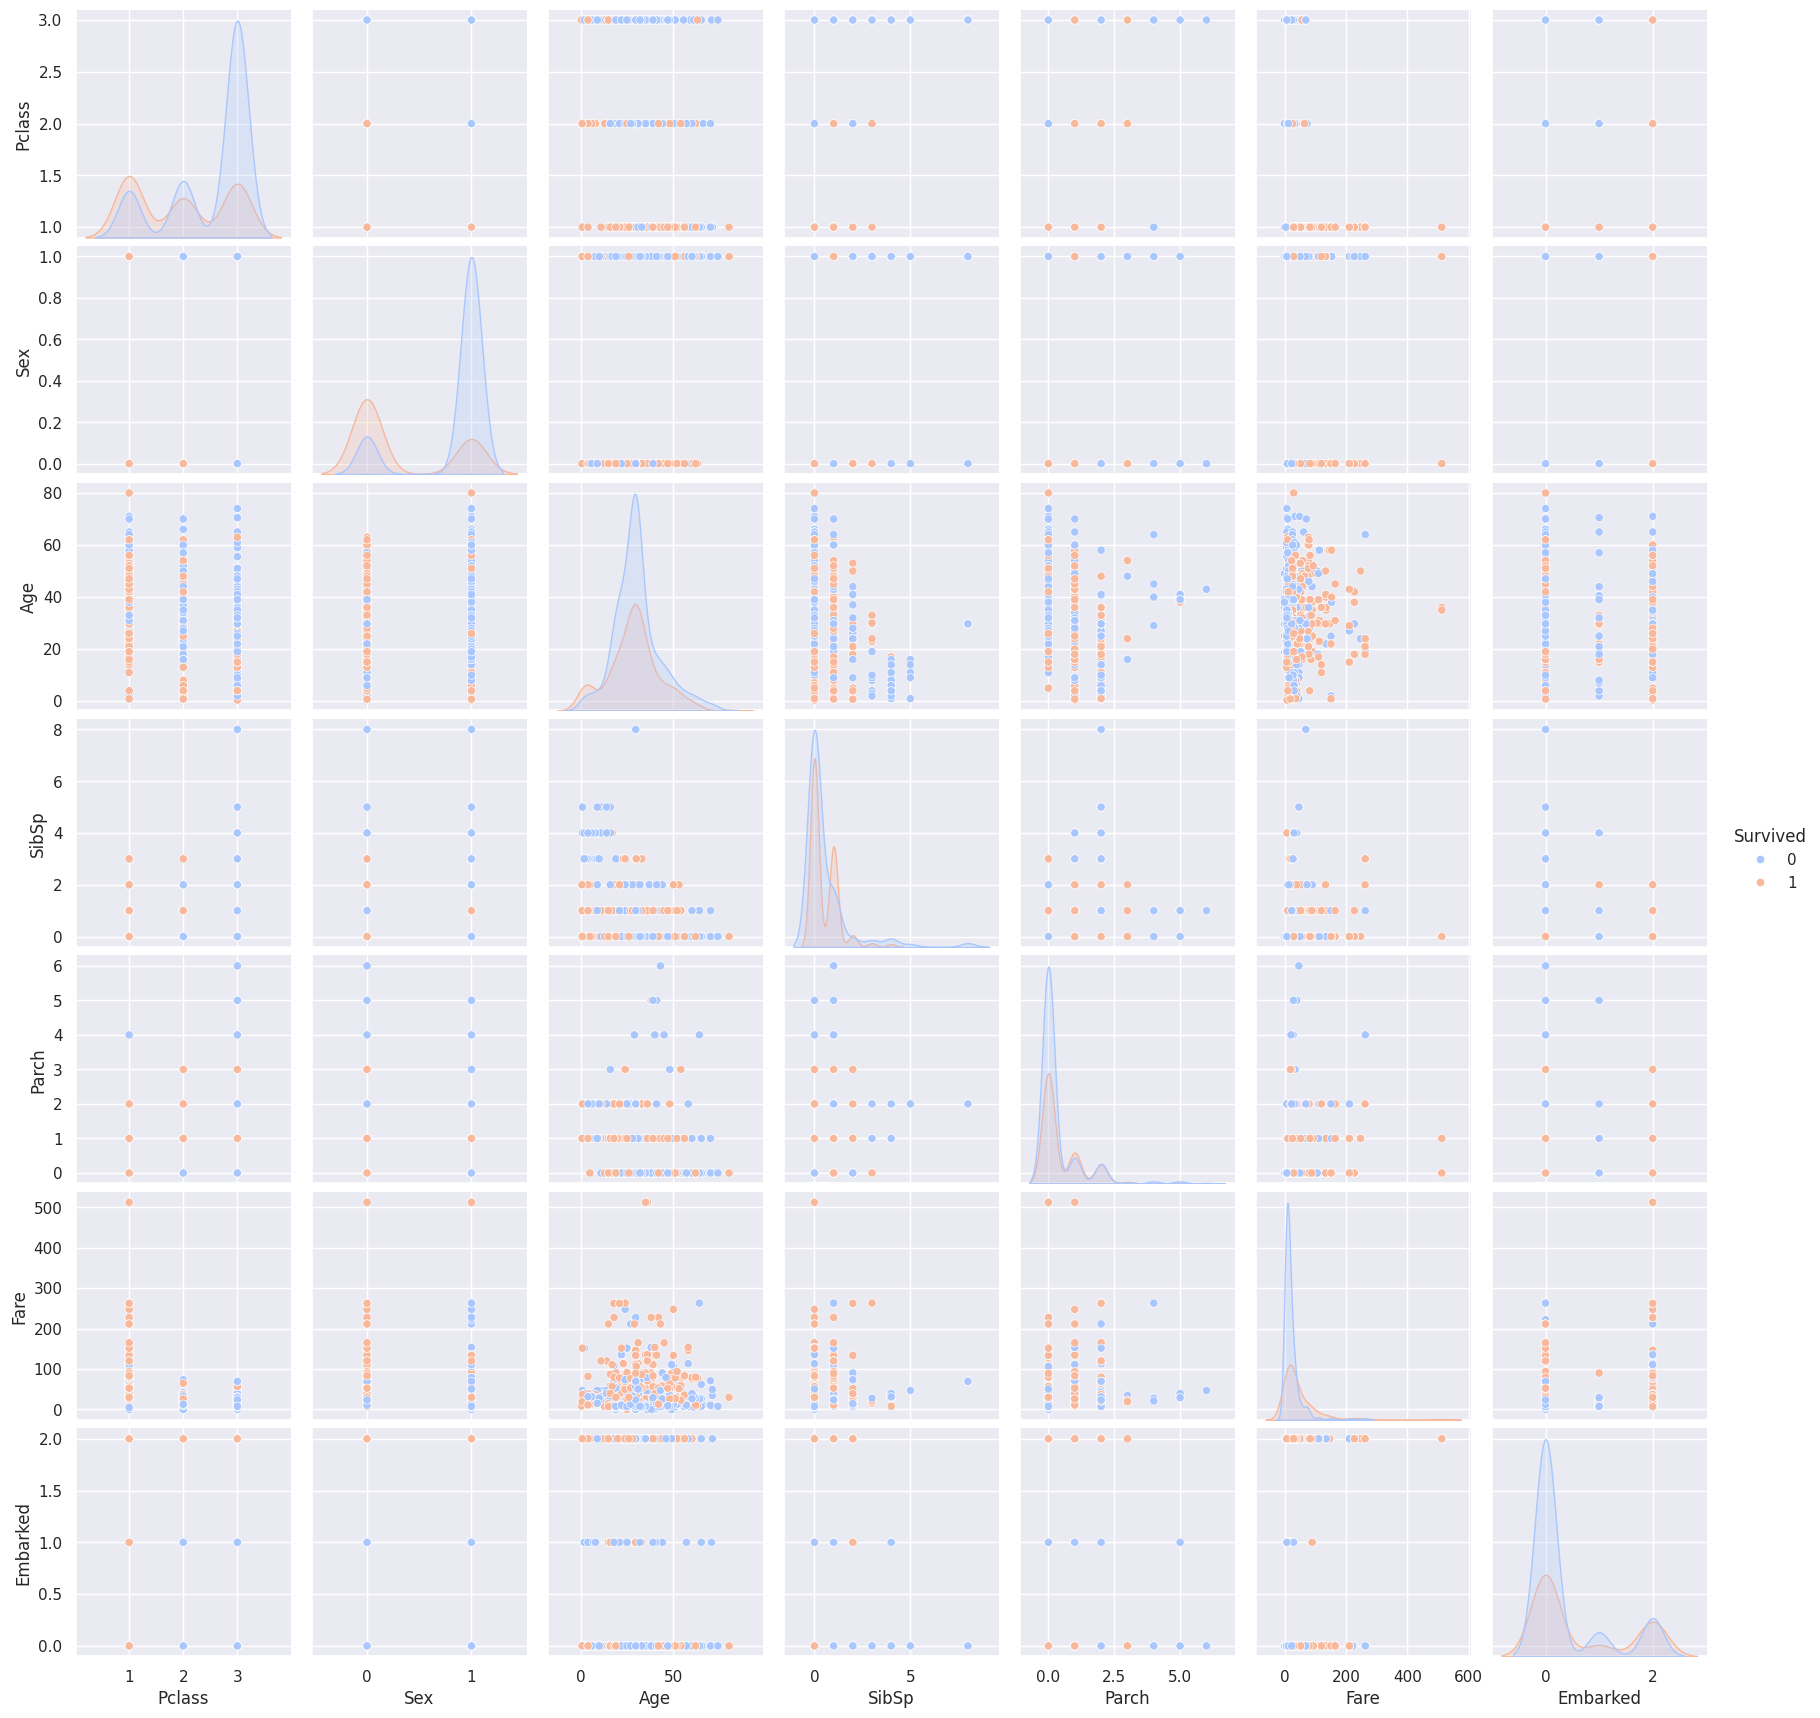

In [109]:
plt.figure(figsize=(10, 10))
sns.pairplot(train, hue='Survived', diag_kind='kde', palette='coolwarm')
plt.show()